# Microscopy Analysis — 96-well

This notebook examines the effect of bead treatment on cell morphology using DIC microscopy images from a 96-well experiment. Single-cell measurements (area and major-axis length) are pooled across wells and replicates for each bead-size condition. Bar charts compare mean morphology against no-bead controls, with statistical comparisons made explicit using Holm-Bonferroni-corrected Welch's t-tests.

In [1]:
from pathlib import Path

import arcadia_pycolor as apc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

apc.mpl.setup()

## Statistical setup

The two helper functions below handle p-value correction and figure annotation. Raw p-values from Welch's t-tests are adjusted using Holm-Bonferroni correction and converted to star notation (`*` p < 0.05, `**` p < 0.01, `***` p < 0.001) placed above the relevant bars in each figure.

In [2]:
def pval_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def correct_pvalues(pvals):
    """Apply Holm-Bonferroni correction, tolerating NaNs."""
    valid_mask = [not np.isnan(p) for p in pvals]
    if not any(valid_mask):
        return list(pvals)
    valid_pvals = [p for p, v in zip(pvals, valid_mask, strict=True) if v]
    _, corrected, _, _ = multipletests(valid_pvals, method="holm")
    corrected_iter = iter(corrected)
    return [next(corrected_iter) if v else np.nan for v in valid_mask]

## Data preparation

Measurements are loaded from `data/microscopy/combined_dic_measurements_96well.csv`. Each row represents a single segmented cell. Treatment strings are mapped to numeric bead sizes for grouping and plotting. The sample below is a quick sanity check that the expected columns are present.

In [3]:
REPO_ROOT = Path().resolve().parent

csv_path = REPO_ROOT / "data" / "microscopy" / "combined_dic_measurements_96well.csv"
df = pd.read_csv(csv_path)

# Map treatment string to numeric bead size
treatment_to_bead_size = {
    "NO bead": 0.0,
    "1 mm bead": 1.0,
    "1.5 mm bead": 1.5,
    "3 mm bead": 3.0,
    "4.5 mm bead": 4.5,
}
df["bead_size_mm"] = df["treatment"].map(treatment_to_bead_size)

df.sample(10, random_state=42).drop("source_file", axis=1)

,axis_major_length,area,length,well_letter,well_num,strain,treatment,bead_size_mm
8423,14.248126,41.589844,14.248126,A,8,SP286,4.5 mm bead,4.5
733,8.569660,29.310938,8.569660,A,1,SP286,1 mm bead,1.0
15122,7.161691,23.263906,7.161691,B,7,SP286,4.5 mm bead,4.5
9841,8.959319,28.149062,8.959319,A,10,SP286,NO bead,0.0
7792,9.155334,26.379844,9.155334,A,8,SP286,4.5 mm bead,4.5
6315,9.081646,25.191562,9.081646,A,6,SP286,3 mm bead,3.0
5170,11.163610,33.139844,11.163610,A,5,SP286,3 mm bead,3.0
1862,14.180524,53.710313,14.180524,A,2,SP286,1 mm bead,1.0
10936,10.648750,42.144375,10.648750,B,3,SP286,1.5 mm bead,1.5
6827,12.691213,42.593281,12.691213,A,7,SP286,4.5 mm bead,4.5


## Cell morphology by bead treatment

`plot_metric_by_bead` produces a bar chart of the mean value of any continuous morphology column grouped by bead size. Error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars reflect Holm-Bonferroni-corrected Welch's t-tests against the no-bead control.

In [ ]:
METRIC_LABELS = {
    "area": "area (μm²)",
    "length": "length (μm)",
}


def plot_metric_by_bead(df, metric, output_filename):
    """Bar plot of mean `metric` by bead size with Holm-Bonferroni-corrected t-tests vs. control."""
    bead_values = df["bead_size_mm"].unique()
    means = df.groupby("bead_size_mm")[metric].mean()
    stds = df.groupby("bead_size_mm")[metric].std()
    counts = df.groupby("bead_size_mm")[metric].count()
    cis = 1.96 * stds / np.sqrt(counts)

    x = np.arange(len(means))
    fig, ax = plt.subplots(figsize=(10, 6), facecolor=apc.parchment)
    ax.bar(x, means, yerr=cis, capsize=6)
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in means.index])
    ax.set_xlabel("Bead size (mm)")
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.set_title(f"Mean cell {metric} by bead treatment (96-well)")

    # Welch's t-test vs control (bead_size == 0), Holm-Bonferroni correction
    control_vals = df[df["bead_size_mm"] == 0.0][metric].values
    treatment_beads = sorted(b for b in bead_values if b != 0.0)
    raw_pvals = []
    for b in treatment_beads:
        treat_vals = df[df["bead_size_mm"] == b][metric].values
        if len(control_vals) > 1 and len(treat_vals) > 1:
            _, p = ttest_ind(control_vals, treat_vals, equal_var=False)
        else:
            p = np.nan
        raw_pvals.append(p)

    adj_pvals = correct_pvalues(raw_pvals)
    y_offset = means.max() * 0.05
    for b, adj_p in zip(treatment_beads, adj_pvals, strict=True):
        stars = pval_to_stars(adj_p)
        if stars:
            bar_idx = list(means.index).index(b)
            ax.text(
                bar_idx, means[b] + cis[b] + y_offset, stars, ha="center", va="bottom", fontsize=14
            )

    ax.set_ylim(bottom=0, top=(means + cis).max() + y_offset * 6)
    apc.mpl.style_plot(ax)
    plt.tight_layout()
    svg_out = REPO_ROOT / "figures" / "figure-4" / output_filename
    fig.savefig(svg_out, bbox_inches="tight", facecolor=apc.parchment)
    return fig


### Cell area

Mean cross-sectional area (μm²) per bead-size condition.

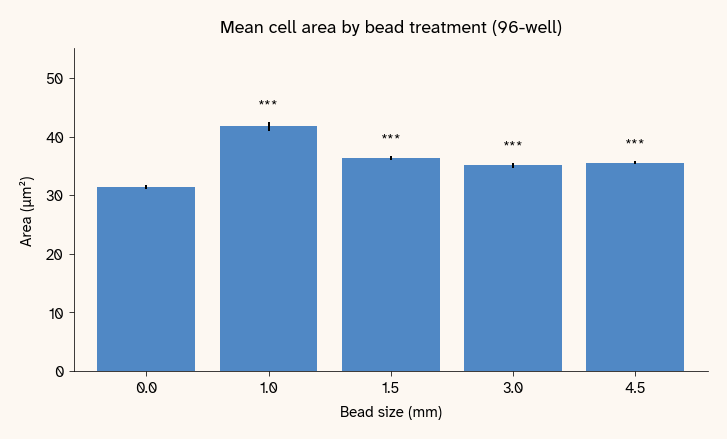

In [5]:
fig_area = plot_metric_by_bead(df, "area", "96-well_bar_plot_area.svg")

### Cell length

Mean major-axis length (μm) per bead-size condition.

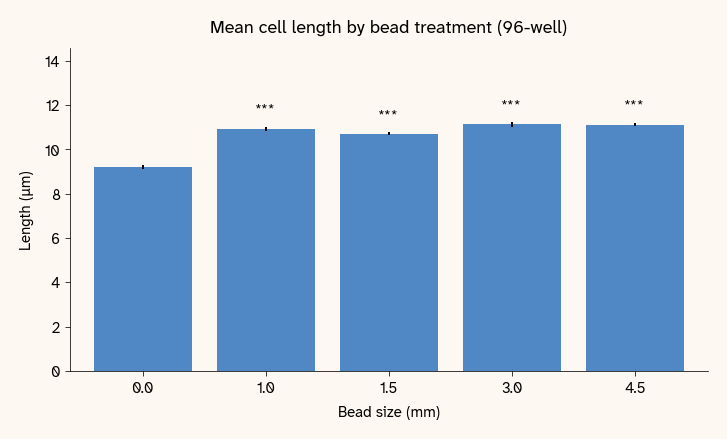

In [6]:
fig_length = plot_metric_by_bead(df, "length", "96-well_bar_plot_length.svg")